In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install mne loguru typer tqdm seaborn tensorflow scikit-learn

In [ ]:
%cd /content/drive/MyDrive/aid-data-analysis-smc-2025-main

/content/drive/MyDrive/aid-data-analysis-smc-2025-main


#Plot

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario_ica")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

#PICKS   = ['CPz']
PICKS   = ['Fz', 'Cz', 'Pz']
COMBINE = 'mean'

STAT_CHANNELS = ['Fz','Cz', 'CPz', 'Pz']

print("Loading Epochs and Extracting...")

evokeds_before = {}
evokeds_after  = {}

total_before = 0
total_after  = 0

for subj in SUBJECTS:
    filepath = ONSET_DIR / f"{subj}-onset-epo.fif"
    if not filepath.exists():
        print(f"  {subj}: file not found, skipping")
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    pos2_options = epochs["Trial_Type == 'Normal' and Is_Target == False and Word_Position == 2"]

    before = pos2_options["Target_Position == 3"]
    after  = pos2_options["Target_Position == 1"]

    total_before += len(before)
    total_after  += len(after)

    if len(before) > 0:
        evokeds_before[subj] = before.average()
    if len(after) > 0:
        evokeds_after[subj] = after.average()

    del epochs

print("-" * 40)
print("DATA SUMMARY:")
print(f"Subjects used: {list(set(evokeds_before.keys()) & set(evokeds_after.keys()))}")
print(f"Total BEFORE (pos2 option, target at pos3): {total_before}")
print(f"Total AFTER  (pos2 option, target at pos1): {total_after}")
print("-" * 40)

# ============
# Grand Average Plot
# ============
print("\nCalculating Grand Averages and plotting...")

ga_before = mne.grand_average(list(evokeds_before.values()))
ga_after  = mne.grand_average(list(evokeds_after.values()))

label_before = f"Before Target (n={total_before})"
label_after  = f"After Target (n={total_after})"

dict_evokeds = {
    label_before: ga_before,
    label_after:  ga_after,
}

plot_kwargs = dict(
    combine=COMBINE,
    title="ERP: Before vs After Target — Position 2 only (controlled)",
    colors={label_before: 'red', label_after: 'blue'},
    styles={label_before: {"linewidth": 2}, label_after: {"linewidth": 2}},
    show=False,
)
if PICKS is not None:
    plot_kwargs["picks"] = PICKS

mne.viz.plot_compare_evokeds(dict_evokeds, **plot_kwargs)
plt.show()

# ===
# Cluster-based Permutation + Cohen's d
# ===
print("\nRunning Statistical Analysis...")

common_subjs = sorted(set(evokeds_before.keys()) & set(evokeds_after.keys()))

list_A = [evokeds_before[s] for s in common_subjs]
list_B = [evokeds_after[s]  for s in common_subjs]

times = list_A[0].times
time_mask = (times >= 0.0) & (times <= 0.800)
times_search = times[time_mask]

available_chs = list_A[0].ch_names

for ch in STAT_CHANNELS:
    if ch not in available_chs:
        print(f"\nChannel {ch}: NOT available, skipping")
        continue

    ch_idx = available_chs.index(ch)
    print(f"\nAnalyzing Channel: {ch}")

    X_diff = np.array([
        list_A[i].data[ch_idx, time_mask] - list_B[i].data[ch_idx, time_mask]
        for i in range(len(common_subjs))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_obs, clusters, cluster_p_values, H0 = \
            mne.stats.permutation_cluster_1samp_test(
                X_diff, n_permutations=1000, seed=42, tail=0, verbose=False
            )

    sig_found = False
    if len(clusters) > 0:
        for i, cluster in enumerate(clusters):
            p_val = cluster_p_values[i]
            if p_val < 0.05:
                time_indices = cluster[0]
                idx_start = time_indices.start if isinstance(time_indices, slice) else time_indices[0]
                idx_stop  = time_indices.stop - 1 if isinstance(time_indices, slice) else time_indices[-1]

                t_start = times_search[idx_start] * 1000
                t_end   = times_search[idx_stop] * 1000

                cluster_data = X_diff[:, idx_start:idx_stop+1].mean(axis=1)
                mean_diff = cluster_data.mean()
                std_diff  = cluster_data.std(ddof=1)
                cohens_d  = mean_diff / std_diff if std_diff > 0 else 0.0

                direction = "BEFORE > AFTER" if mean_diff > 0 else "AFTER > BEFORE"

                print(f"  [***] CLUSTER: {t_start:.1f} to {t_end:.1f} ms | p={p_val:.4f} | {direction} | Cohen's d={cohens_d:.3f}")
                sig_found = True

    if not sig_found:
        print("  -> No significant differences found.")

#Confidence interval

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PICKS = ['Fz', 'CPz', 'Pz']

common_subjs = sorted(set(evokeds_before.keys()) & set(evokeds_after.keys()))

available = evokeds_before[common_subjs[0]].ch_names
pick_idx  = [available.index(ch) for ch in PICKS if ch in available]
times     = evokeds_before[common_subjs[0]].times

diffs = []
for s in common_subjs:
    b = evokeds_before[s].data[pick_idx, :].mean(axis=0)
    a = evokeds_after[s].data[pick_idx, :].mean(axis=0)
    diffs.append((b - a) * 1e6)

diffs = np.array(diffs)
n = len(common_subjs)

mean_diff = diffs.mean(axis=0)
sem = diffs.std(axis=0, ddof=1) / np.sqrt(n)
ci95 = 1.96 * sem

plt.figure(figsize=(11, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.plot(times, mean_diff, color='purple', linewidth=2, label='Before - After (mean)')
plt.fill_between(times, mean_diff - ci95, mean_diff + ci95,
                 color='purple', alpha=0.25, label='95% CI')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude difference (µV)")
plt.title(f"Difference wave with 95% CI (n={n} subjects)")
plt.legend()
plt.tight_layout()
plt.show()

#EEGNet

In [ ]:
import mne
import numpy as np
from pathlib import Path
import gc

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
   # "sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

data_list, target_list, subject_list = [], [], []

for subj in SUBJECTS:
    input_file = ONSET_DIR / f"{subj}-onset-epo.fif"
    epochs = mne.read_epochs(input_file, preload=True, verbose=False)
    epochs.resample(128, verbose=False)

    pos2_options = epochs["Trial_Type == 'Normal' and Is_Target == False and Word_Position == 2"]
    before = pos2_options["Target_Position == 3"]
    after = pos2_options["Target_Position == 1"]

    for epoch_set, target in [(before, 0), (after, 1)]:
        d = epoch_set.get_data().astype(np.float32)
        data_list.append(d)
        target_list.append(np.full(len(d), target))
        subject_list.append(np.full(len(d), subj))

    print(f"{subj}: before={len(before)}, after={len(after)}")

    del epochs, pos2_options, before, after
    gc.collect()

data = np.concatenate(data_list, axis=0)
targets = np.concatenate(target_list, axis=0)
subject_ids = np.concatenate(subject_list, axis=0)

del data_list, target_list, subject_list
gc.collect()

print()
print(f"data shape: {data.shape}")
print(f"Total BEFORE (pos2 option, target at pos3): {np.sum(targets == 0)}")
print(f"Total AFTER  (pos2 option, target at pos1): {np.sum(targets == 1)}")
print(f"subjects: {len(np.unique(subject_ids))}")

sub-01: before=48, after=56
sub-02: before=51, after=57
sub-04: before=61, after=49
sub-05: before=54, after=54
sub-07: before=48, after=52
sub-08: before=53, after=53
sub-09: before=50, after=60
sub-10: before=51, after=54
sub-11: before=47, after=47

data shape: (945, 126, 154)
Total BEFORE (pos2 option, target at pos3): 463
Total AFTER  (pos2 option, target at pos1): 482
subjects: 9


In [ ]:
import sys
import numpy as np
import pandas as pd
import mne
import gc
from sklearn import metrics
from sklearn.model_selection import LeaveOneGroupOut
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

sys.path.append("/content/drive/MyDrive/aid-data-analysis-smc-2025-main/aid_data_analysis/external")
from EEGModels import EEGNet

N_EPOCHS = 50


def eegnet_reshape(data):
    return data.reshape((data.shape[0], data.shape[1], data.shape[2], 1))


labels_onehot = np.stack([-targets + 1, targets], axis=1)

logo = LeaveOneGroupOut()
splits = logo.split(data, targets, subject_ids)
n_splits = len(np.unique(subject_ids))

accuracies = []
f1_scores = []
prediction_rows = []

for i, split in enumerate(splits):
    data_train = data[split[0]]
    labels_train = labels_onehot[split[0]]

    data_test = data[split[1]]
    labels_test = labels_onehot[split[1]]
    subject_ids_test = subject_ids[split[1]]

    held_out = np.unique(subject_ids_test)[0]
    print(f"\n--- Split {i + 1}/{n_splits} | held out: {held_out} ---")

    scaler = mne.decoding.Scaler(scalings="median")
    data_train_scaled = scaler.fit_transform(data_train)
    data_test_scaled = scaler.transform(data_test)

    data_train_scaled_shaped = eegnet_reshape(data_train_scaled)
    data_test_scaled_shaped = eegnet_reshape(data_test_scaled)

    model = EEGNet(2, 126, data_train_scaled_shaped.shape[-2])
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    model.fit(data_train_scaled_shaped, labels_train, epochs=N_EPOCHS, batch_size=32, verbose=0)

    argmax_labels = np.argmax(labels_test, axis=1)
    argmax_predictions = np.argmax(model.predict(data_test_scaled_shaped, verbose=0), axis=1)

    accuracies.append(metrics.accuracy_score(argmax_labels, argmax_predictions))
    f1_scores.append(metrics.f1_score(argmax_labels, argmax_predictions, average='weighted'))

    print(f"{held_out} -> Accuracy: {accuracies[-1]:.4f} | F1: {f1_scores[-1]:.4f}")

    prediction_rows.append(pd.DataFrame({
        "prediction": argmax_predictions,
        "label": argmax_labels,
        "subject": subject_ids_test
    }))

    del model, data_train, data_test, data_train_scaled, data_test_scaled
    del data_train_scaled_shaped, data_test_scaled_shaped
    K.clear_session()
    gc.collect()

prediction_df = pd.concat(prediction_rows, ignore_index=True)

print()
print(f"Mean Accuracy: {np.mean(accuracies):.4f} +/- {np.std(accuracies):.4f}")
print(f"Mean F1 Score: {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}")


--- Split 1/9 | held out: sub-01 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-01 -> Accuracy: 0.5769 | F1: 0.5611

--- Split 2/9 | held out: sub-02 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-02 -> Accuracy: 0.5370 | F1: 0.5370

--- Split 3/9 | held out: sub-04 ---


...

sub-09 -> Accuracy: 0.5727 | F1: 0.5735

--- Split 8/9 | held out: sub-10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-10 -> Accuracy: 0.5524 | F1: 0.5516

--- Split 9/9 | held out: sub-11 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-11 -> Accuracy: 0.5000 | F1: 0.4999

Mean Accuracy: 0.5378 +/- 0.0499
Mean F1 Score: 0.5356 +/- 0.0493


Baseline accuracy: 0.5376
Baseline F1 score: 0.5375



100%|██████████| 10000/10000 [01:56<00:00, 86.07it/s]
/tmp/ipykernel_1036/4073464483.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_per_subject = prediction_df.groupby("subject").apply(get_accuracy).reset_index()
/tmp/ipykernel_1036/4073464483.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=accuracy_per_subject, x="subject", y="accuracy", palette="colorblind")



Accuracy p-value: 0.0156 (156/10000)
F1-score p-value: 0.0156 (156/10000)
Statistically significant (p < 0.05)


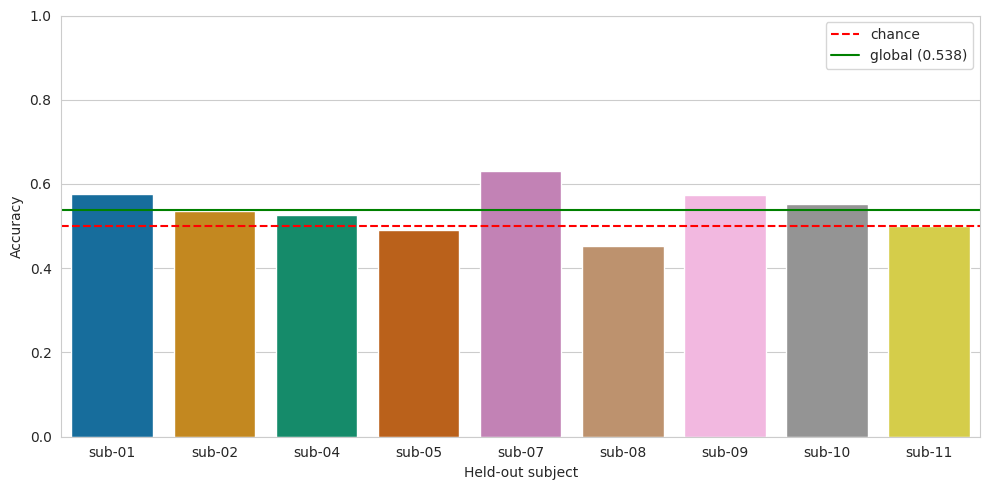

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn import metrics
from tqdm import tqdm

N_PERMUTATIONS = 10000
rng = np.random.default_rng(seed=42)


def get_accuracy(df):
    return df[df["prediction"] == df["label"]].shape[0] / df.shape[0]


def get_f1_score(df):
    return metrics.f1_score(df["label"], df["prediction"], average="weighted")


def shuffle_per(df, per_col, shuffle_col, rng):
    df_copy = deepcopy(df)
    for item in set(df[per_col]):
        sub_indices = (df_copy[per_col] == item)
        df_copy.loc[sub_indices, shuffle_col] = rng.permutation(df_copy.loc[sub_indices, shuffle_col])
    return df_copy


accuracy_baseline = get_accuracy(prediction_df)
f1_baseline = get_f1_score(prediction_df)

print(f"Baseline accuracy: {accuracy_baseline:.4f}")
print(f"Baseline F1 score: {f1_baseline:.4f}")
print()

larger_acc_count = 0
larger_f1_count = 0

for _ in tqdm(range(N_PERMUTATIONS)):
    shuffled_df = shuffle_per(prediction_df, "subject", "prediction", rng)
    if get_accuracy(shuffled_df) >= accuracy_baseline:
        larger_acc_count += 1
    if get_f1_score(shuffled_df) >= f1_baseline:
        larger_f1_count += 1

p_value_accuracy = larger_acc_count / N_PERMUTATIONS
p_value_f1 = larger_f1_count / N_PERMUTATIONS

print()
print("=" * 45)
print(f"Accuracy p-value: {p_value_accuracy:.4f} ({larger_acc_count}/{N_PERMUTATIONS})")
print(f"F1-score p-value: {p_value_f1:.4f} ({larger_f1_count}/{N_PERMUTATIONS})")
print("=" * 45)
if p_value_accuracy < 0.05:
    print("Statistically significant (p < 0.05)")
else:
    print("Not statistically significant (p >= 0.05)")

accuracy_per_subject = prediction_df.groupby("subject").apply(get_accuracy).reset_index()
accuracy_per_subject.columns = ["subject", "accuracy"]

sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=accuracy_per_subject, x="subject", y="accuracy", palette="colorblind")
ax.axhline(0.5, color="red", linestyle="--", label="chance")
ax.axhline(accuracy_baseline, color="green", label=f"global ({accuracy_baseline:.3f})")
ax.set(xlabel="Held-out subject", ylabel="Accuracy", ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

#In which timstamp?

Significant time windows (accuracy > chance):
  none


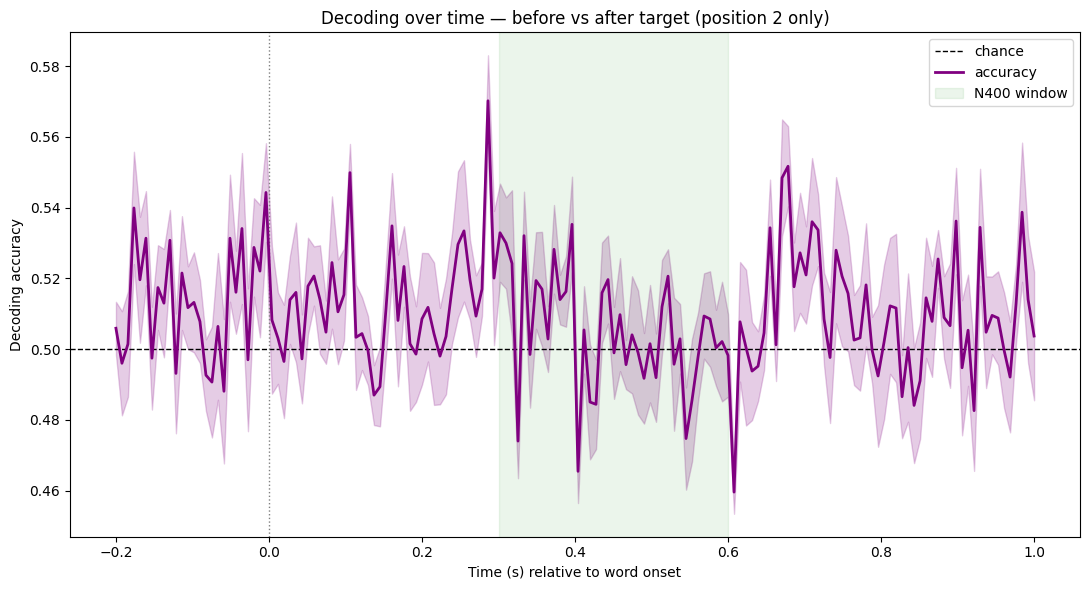

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import warnings

times = np.linspace(-0.2, 1.0, scores.shape[1])

mean_scores = scores.mean(axis=0)
sem_scores = scores.std(axis=0, ddof=1) / np.sqrt(scores.shape[0])

X_diff = scores - 0.5

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    t_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        X_diff, n_permutations=10000, seed=42, tail=1, verbose=False
    )

print("Significant time windows (accuracy > chance):")
sig_mask = np.zeros(len(times), dtype=bool)
found = False
for c, p in zip(clusters, cluster_p_values):
    if p < 0.05:
        idx = c[0]
        i0 = idx.start if isinstance(idx, slice) else idx[0]
        i1 = idx.stop - 1 if isinstance(idx, slice) else idx[-1]
        sig_mask[i0:i1 + 1] = True
        peak = mean_scores[i0:i1 + 1].max()
        print(f"  {times[i0]*1000:.0f} to {times[i1]*1000:.0f} ms | p={p:.4f} | peak acc={peak:.4f}")
        found = True
if not found:
    print("  none")

plt.figure(figsize=(11, 6))
plt.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.plot(times, mean_scores, color="purple", linewidth=2, label="accuracy")
plt.fill_between(times, mean_scores - sem_scores, mean_scores + sem_scores,
                 color="purple", alpha=0.2)
if sig_mask.any():
    plt.fill_between(times, 0, 1, where=sig_mask, color="orange", alpha=0.15,
                     transform=plt.gca().get_xaxis_transform(), label="p < 0.05")
plt.axvspan(0.3, 0.6, color="green", alpha=0.08, label="N400 window")
plt.xlabel("Time (s) relative to word onset")
plt.ylabel("Decoding accuracy")
plt.title("Decoding over time — before vs after target (position 2 only)")
plt.legend()
plt.tight_layout()
plt.show()